In [1]:
import numpy as np, torch, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, matplotlib.colors as mcolors
import rasterio
from rasterio.transform import Affine
from pathlib import Path
from config import TrainConfig, ModelConfig
from model_config import make_model
from inference import FloodInference

cfg  = TrainConfig()
mcfg = ModelConfig()
PATCH_SIZE = mcfg.patch_size

# ── Visual setup ──────────────────────────────────────────────────────────────
FLOOD_COLORS = {
     0: '#FFFFFF',
     1: '#C6DBEF',
     2: '#6BAED6',
     3: '#2171B5',
     4: '#08306B',
}
FLOOD_LABELS = {0: 'No Flood', 1: 'Light', 2: 'Moderate', 3: 'Heavy', 4: 'Extreme'}

conf_cmap  = 'RdYlGn'
flood_colors_rgba = [(1.0, 1.0, 1.0, 0.0), mcolors.to_rgba('#C6DBEF'), mcolors.to_rgba('#6BAED6'),  mcolors.to_rgba('#2171B5'),  mcolors.to_rgba('#08306B'), ]
flood_cmap = mcolors.ListedColormap(flood_colors_rgba)
flood_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], ncolors=5)

legend_patches = [
    mpatches.Patch(facecolor='none', edgecolor='gray', linewidth=1.0, linestyle='--', label='Class 0 — No Flood'),
    *[
        mpatches.Patch(facecolor=FLOOD_COLORS[i], edgecolor='gray',
                       linewidth=0.5, label=f'Class {i} — {FLOOD_LABELS[i]}')
        for i in range(1, 5)
    ]
]

# ── Spatial data ──────────────────────────────────────────────────────────────
data                 = np.load(cfg.output_dir / 'spatial_data.npz')
X_full               = data['spatial']
manila_patch_indices = data['manila_patch_indices']
rain_min, rain_max   = float(data['rain_min'].item()), float(data['rain_max'].item())
N_H, N_W             = int(data['n_h'].item()),        int(data['n_w'].item())

# ── GeoTIFF transform ────────────────────────────────────────────────────────
with rasterio.open('COP-30m-GMM/greater_mm_bbox_dem_cop.tif') as src:
    t = src.transform
    dem_crs = src.crs
dem_transform = Affine(t.a * PATCH_SIZE, 0, t.c, 0, t.e * PATCH_SIZE, t.f)

# ── Model ─────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = make_model(ModelConfig()).to(device)

ckpt_files = sorted(cfg.output_dir.glob('fold_*/best_model.pt'))
if not ckpt_files:
    raise FileNotFoundError(f"No checkpoints in {cfg.output_dir}")

best_ckpt = max(ckpt_files, key=lambda f: torch.load(f, map_location='cpu', weights_only=False).get('best_monitor', -np.inf))
ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

# ── Inference engine ──────────────────────────────────────────────────────────
engine = FloodInference(
    model       = model,
    device      = device,
    rain_min    = rain_min,
    rain_max    = rain_max,
    X_spatial   = X_full,
    num_classes = cfg.num_classes,
    batch_size  = cfg.batch_size,
    manila_patch_indices = manila_patch_indices, 
)

print(f"Grid: {N_H}x{N_W}  |  Transform: {dem_transform.a:.0f}m pixels  |  CRS: {dem_crs}")


FLOOD INFERENCE ENGINE READY
  Device         : cpu
  Model          : ViT
  Spatial patches: 6,480 (Manila mask)
  Patch shape    : (4, 4, 3)
  Rain range     : [0.0000, 189.8531]
  Num classes    : 5
  Batch size     : 256
  Manila indices : 6,480 patches indexed

Grid: 306x281  |  Transform: 120m pixels  |  CRS: EPSG:3857


In [ ]:
# ── Helper functions ──────────────────────────────────────────────────────────
def build_subtitle(cfg_dict):
    parts = [f"Storm: {cfg_dict['storm_type']}", f"Depth: {cfg_dict['depth_mm']} mm"]
    if cfg_dict.get('tpeak') is not None:
        parts.append(f"tpeak: {cfg_dict['tpeak']}")
    return '  |  '.join(parts)

def compute_class_pcts(flood_map):
    total = flood_map.size
    return {i: 100 * (flood_map == i).sum() / total for i in range(5)}


def save_result_as_tif(flood_map, conf_map, config, save_path, transform=None, crs=None):
    H, W = flood_map.shape
    with rasterio.open(
        save_path, mode='w', driver='GTiff',
        height=H, width=W, count=2, dtype='float32',
        crs=crs, transform=transform, compress='lzw',
        nodata=0.0,                                     
    ) as dst:
        dst.write(flood_map.astype(np.float32), 1)
        dst.write(conf_map.astype(np.float32),  2)
        dst.update_tags(1, description='Flood Hazard Class (0=None 1=Light 2=Moderate 3=Heavy 4=Extreme)')
        dst.update_tags(2, description='Model Confidence (softmax max-probability per patch 0.0-1.0)')
        dst.update_tags(
            model      = 'EXP-DES-3 ViTFloodClassifier',
            storm_type = config['storm_type'],
            depth_mm   = str(config['depth_mm']),
            tpeak      = str(config.get('tpeak')),
        )
    print(f"  ✓ GeoTIFF saved → {save_path}")


Test 1/4
Predicting 6,480 patches (batch_size=256)...
  checkmark 1,280/6,480 patches
  checkmark 2,560/6,480 patches
  checkmark 3,840/6,480 patches
  checkmark 5,120/6,480 patches
  checkmark 6,400/6,480 patches
  checkmark 6,480/6,480 patches

PREDICTION SUMMARY
  Storm type     : triangular
  Depth          : 9 mm
  tpeak          : 0.5
  No warnings    : inputs within training range

  Confidence stats (Manila patches):
    Mean      : 0.7088
    Std       : 0.1978
    Min       : 0.3205
    Max       : 1.0000
    Uncertain : 28.3%  (conf < 0.5)

  Flood class distribution (Manila patches):
    No Flood    :   4,415 patches   68.1%  ##################################
    Light       :   1,806 patches   27.9%  #############
    Moderate    :     157 patches    2.4%  #
    Heavy       :      93 patches    1.4%  
    Extreme     :       9 patches    0.1%  


Test 2/4
Predicting 6,480 patches (batch_size=256)...
  checkmark 1,280/6,480 patches
  checkmark 2,560/6,480 patches
  checkm

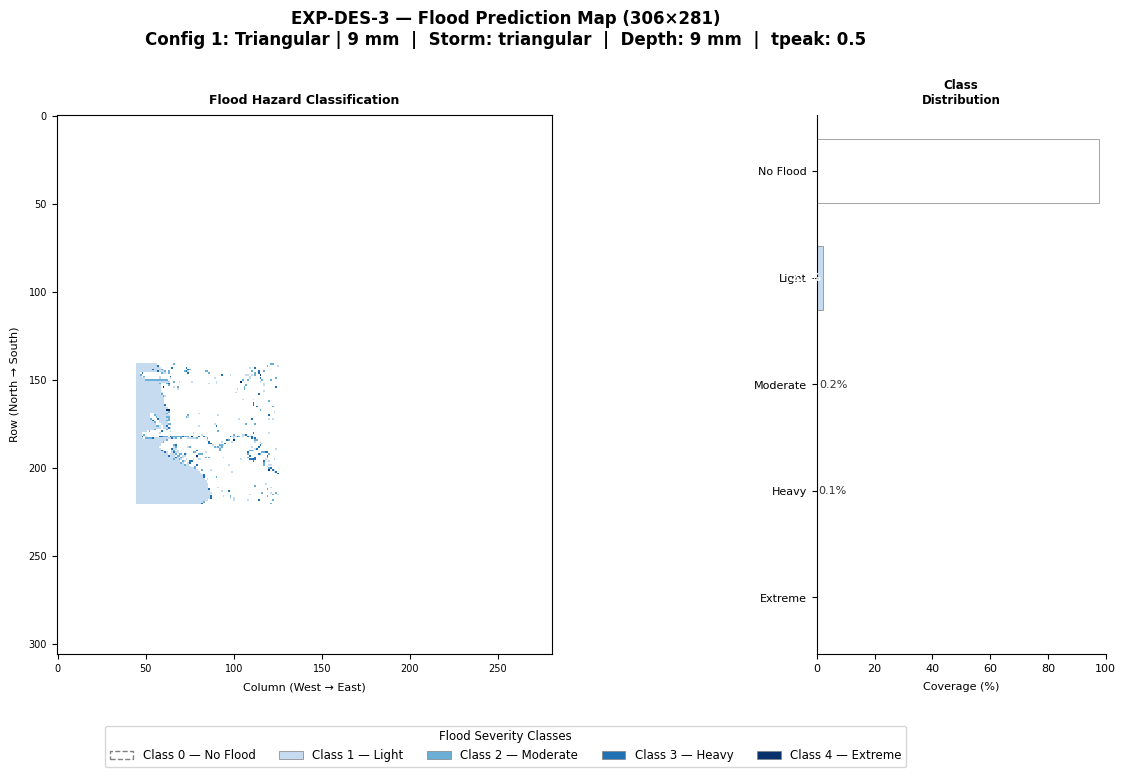

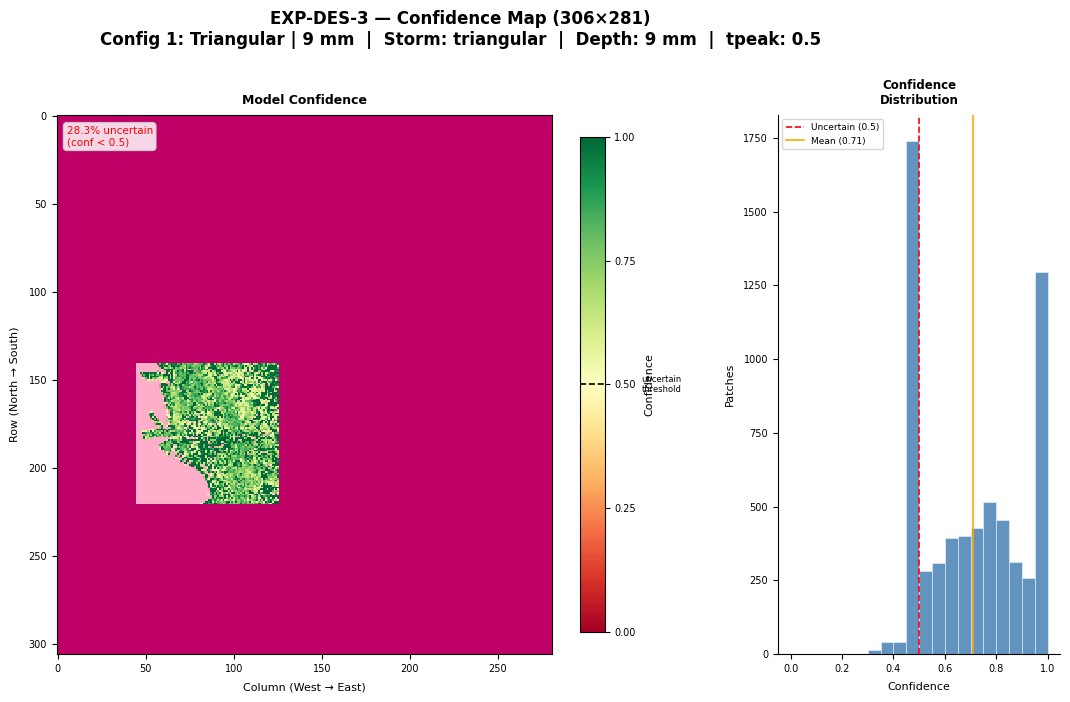

  ✓ GeoTIFF saved → checkpoints\web_config1_result.tif


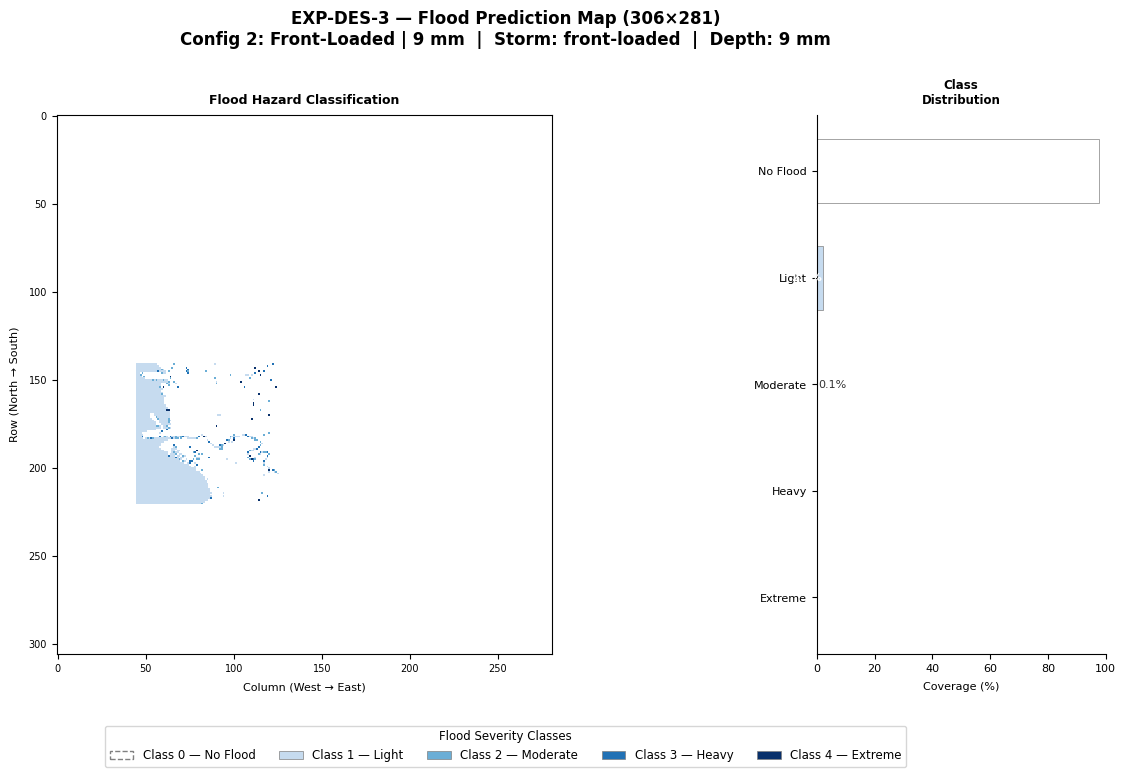

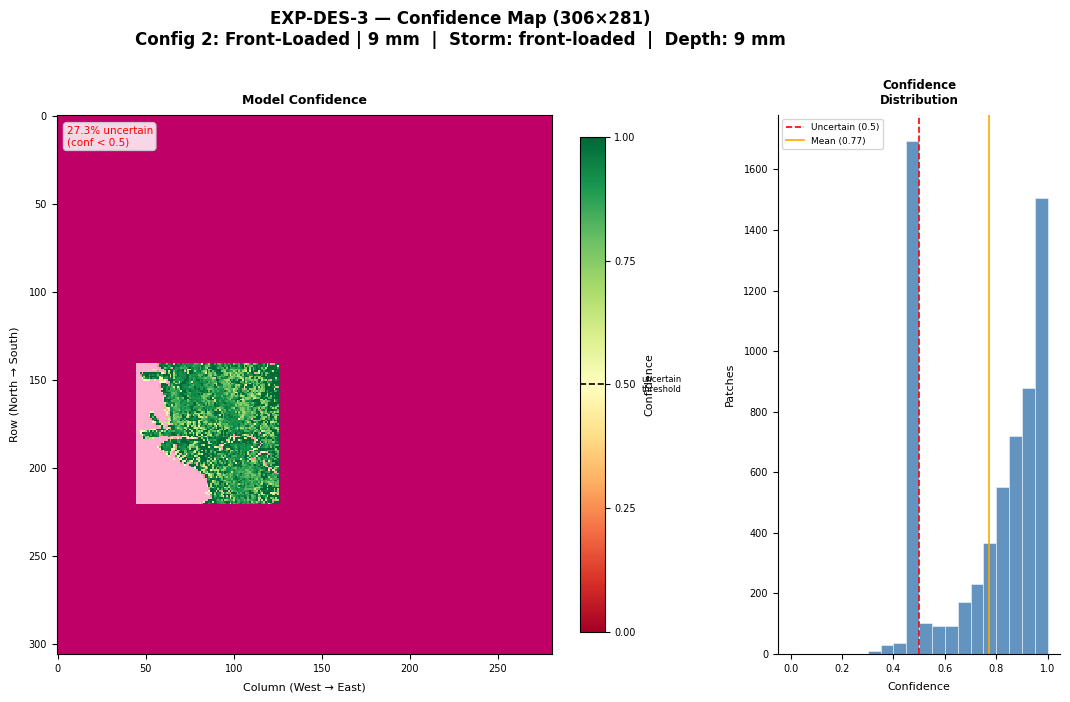

  ✓ GeoTIFF saved → checkpoints\web_config2_result.tif


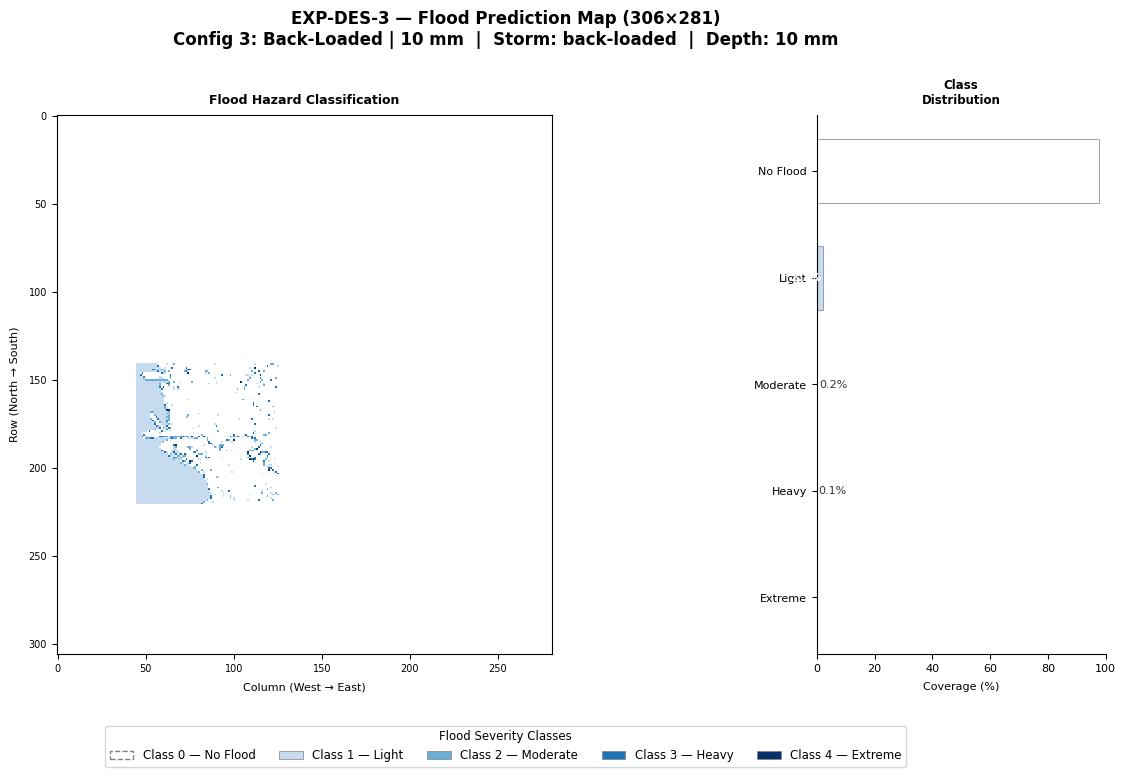

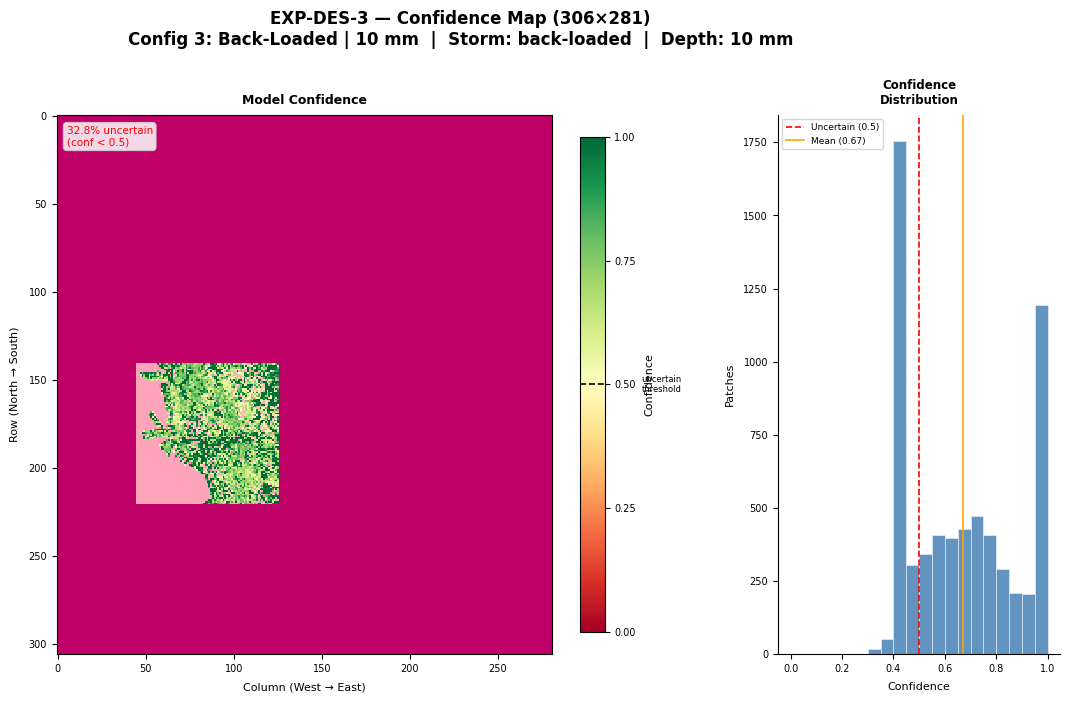

  ✓ GeoTIFF saved → checkpoints\web_config3_result.tif


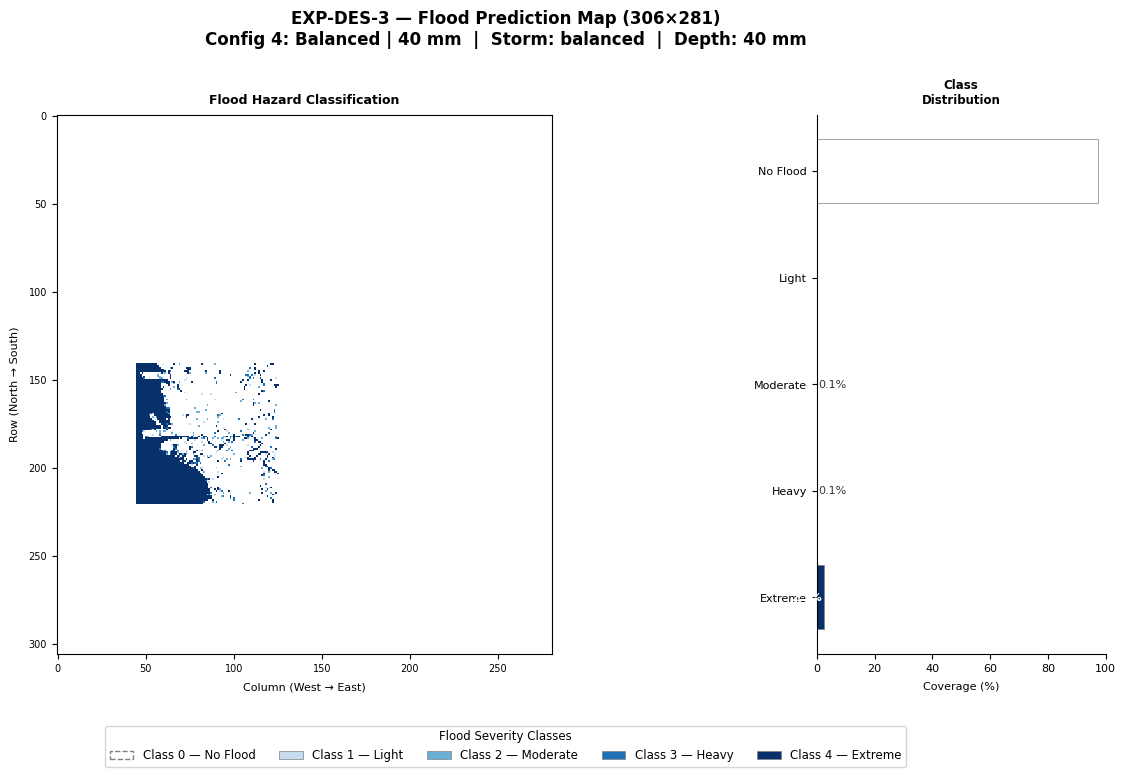

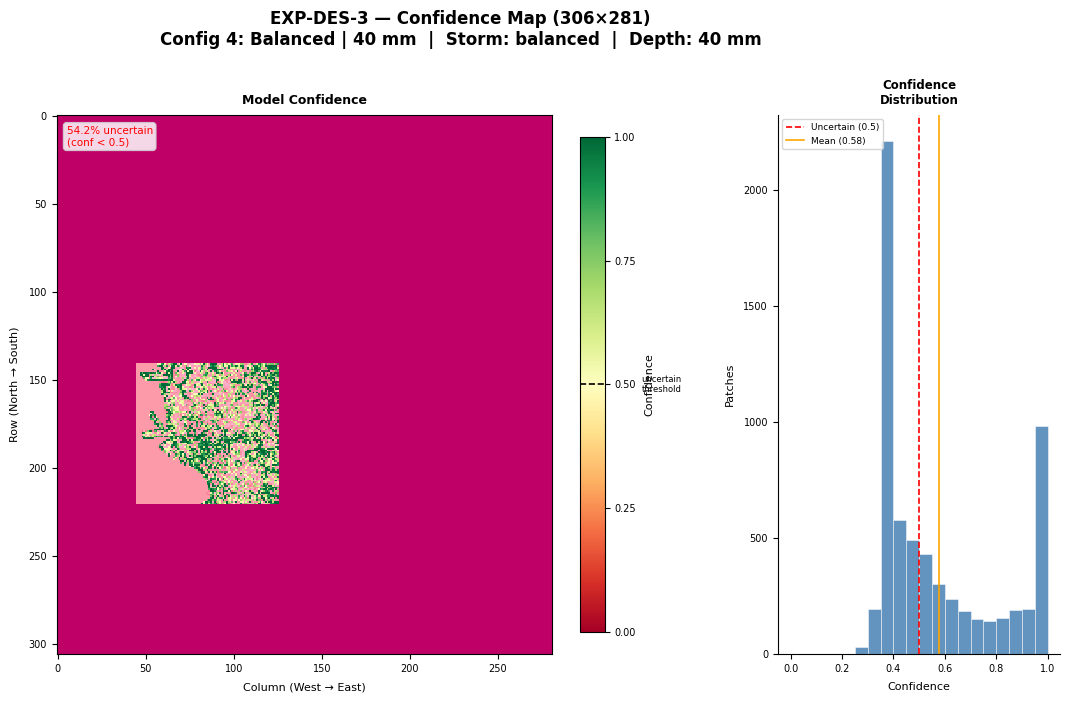

  ✓ GeoTIFF saved → checkpoints\web_config4_result.tif

✓ All configurations processed.


In [3]:
# ── Test configurations ───────────────────────────────────────────────────────
test_configs = [
    {'storm_type': 'triangular',   'depth_mm': 9,  'tpeak': 0.5},
    {'storm_type': 'front-loaded', 'depth_mm': 9,  'tpeak': None},
    {'storm_type': 'back-loaded',  'depth_mm': 10, 'tpeak': None},
    {'storm_type': 'balanced',     'depth_mm': 40, 'tpeak': None},
]

results = engine.predict_batch(test_configs, n_h=N_H, n_w=N_W)

# ══════════════════════════════════════════════════════════════════════════════
# Plotting + GeoTIFF export loop
# ══════════════════════════════════════════════════════════════════════════════
for i, (result, config) in enumerate(zip(results, test_configs)):
    cfg_label = f"Config {i+1}: {config['storm_type'].title()} | {config['depth_mm']} mm"

    if 'error' in result:
        print(f"\n{cfg_label}: ERROR — {result['error']}")
        continue

    flood_map   = result['flood_map'].astype(np.float32)
    conf_map    = result['conf_map'].astype(np.float32)
    patch_confs = result['patch_confidences']
    warnings    = result.get('warnings', [])
    pcts        = compute_class_pcts(flood_map)
    frac_low    = (patch_confs < 0.5).mean() * 100
    subtitle    = build_subtitle(config)

    # ─────────────────────────────────────────────────────────────────────────
    # Figure 1 — Flood Map
    # ─────────────────────────────────────────────────────────────────────────
    fig1, axes1 = plt.subplots(
        1, 2, figsize=(15, 7),
        gridspec_kw={'width_ratios': [2.5, 1], 'wspace': 0.30}
    )
    ax_flood, ax_bar = axes1

    fig1.suptitle(
        f'EXP-DES-3 — Flood Prediction Map ({N_H}×{N_W})\n{cfg_label}  |  {subtitle}',
        fontsize=12, fontweight='bold', y=1.03
    )

    ax_flood.imshow(flood_map, cmap=flood_cmap, norm=flood_norm,
                    interpolation='nearest', origin='upper')
    ax_flood.set_title('Flood Hazard Classification', fontsize=9, fontweight='bold', pad=8)
    ax_flood.set_xlabel('Column (West → East)', fontsize=8, labelpad=6)
    ax_flood.set_ylabel('Row (North → South)', fontsize=8, labelpad=6)
    ax_flood.tick_params(labelsize=7)

    labels = [FLOOD_LABELS[j] for j in range(5)]
    values = [pcts[j]         for j in range(5)]
    colors = [FLOOD_COLORS[j] for j in range(5)]
    bars   = ax_bar.barh(labels, values, color=colors,
                         edgecolor='gray', linewidth=0.5, height=0.6)
    for bar, val in zip(bars, values):
        if val > 1.5:
            ax_bar.text(bar.get_width() - 0.5,
                        bar.get_y() + bar.get_height() / 2,
                        f'{val:.1f}%', va='center', ha='right',
                        fontsize=8, color='white', fontweight='bold')
        elif val > 0.1:
            ax_bar.text(bar.get_width() + 0.5,
                        bar.get_y() + bar.get_height() / 2,
                        f'{val:.1f}%', va='center', ha='left',
                        fontsize=8, color='#333333')

    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel('Coverage (%)', fontsize=8, labelpad=6)
    ax_bar.set_title('Class\nDistribution', fontsize=8.5, fontweight='bold', pad=8)
    ax_bar.tick_params(axis='both', labelsize=8)
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.invert_yaxis()

    fig1.legend(
        handles=legend_patches, loc='lower center', ncol=5,
        fontsize=8.5, frameon=True,
        title='Flood Severity Classes', title_fontsize=8.5,
        bbox_to_anchor=(0.5, -0.06)
    )

    plt.savefig(
        str(cfg.output_dir / f'web_config{i+1}_flood_map.png'),
        dpi=150, bbox_inches='tight', facecolor='white'
    )
    plt.show()
    plt.close(fig1)

    # ─────────────────────────────────────────────────────────────────────────
    # Figure 2 — Confidence Map
    # ─────────────────────────────────────────────────────────────────────────
    fig2, axes2 = plt.subplots(
        1, 2, figsize=(15, 7),
        gridspec_kw={'width_ratios': [2.5, 1], 'wspace': 0.35}
    )
    ax_conf, ax_hist = axes2

    fig2.suptitle(
        f'EXP-DES-3 — Confidence Map ({N_H}×{N_W})\n{cfg_label}  |  {subtitle}',
        fontsize=12, fontweight='bold', y=1.03
    )

    im = ax_conf.imshow(conf_map, cmap=conf_cmap, vmin=0.0, vmax=1.0,
                        interpolation='nearest', origin='upper')
    ax_conf.set_title('Model Confidence', fontsize=9, fontweight='bold', pad=8)
    ax_conf.set_xlabel('Column (West → East)', fontsize=8, labelpad=6)
    ax_conf.set_ylabel('Row (North → South)', fontsize=8, labelpad=6)
    ax_conf.tick_params(labelsize=7)

    cbar = fig2.colorbar(im, ax=ax_conf, fraction=0.035, pad=0.04)
    cbar.set_label('Confidence', fontsize=8, labelpad=6)
    cbar.ax.tick_params(labelsize=7)
    cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])
    cbar.ax.axhline(y=0.5, color='black', linewidth=1.2, linestyle='--')
    cbar.ax.text(2.5, 0.5, 'uncertain\nthreshold', fontsize=6, va='center')

    uncertain_overlay = conf_map.copy().astype(float)
    uncertain_overlay[conf_map >= 0.5] = np.nan
    uncertain_overlay[conf_map <  0.5] = 1.0
    ax_conf.imshow(uncertain_overlay, cmap='cool', alpha=0.30,
                   vmin=0, vmax=1, interpolation='nearest', origin='upper')
    ax_conf.text(
        0.02, 0.98,
        f'{frac_low:.1f}% uncertain\n(conf < 0.5)',
        transform=ax_conf.transAxes, ha='left', va='top', fontsize=7.5,
        color='red' if frac_low > 20 else 'gray',
        bbox=dict(boxstyle='round,pad=0.30', facecolor='white',
                  edgecolor='lightgray', alpha=0.85)
    )

    ax_hist.hist(patch_confs, bins=20, range=(0, 1),
                 color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax_hist.axvline(x=0.5, color='red', linewidth=1.2, linestyle='--',
                    label='Uncertain (0.5)')
    ax_hist.axvline(x=patch_confs.mean(), color='orange', linewidth=1.2,
                    label=f"Mean ({patch_confs.mean():.2f})")
    ax_hist.set_xlabel('Confidence', fontsize=8, labelpad=6)
    ax_hist.set_ylabel('Patches', fontsize=8, labelpad=6)
    ax_hist.set_title('Confidence\nDistribution', fontsize=8.5, fontweight='bold', pad=8)
    ax_hist.tick_params(labelsize=7)
    ax_hist.legend(fontsize=6.5, loc='upper left')
    ax_hist.spines['top'].set_visible(False)
    ax_hist.spines['right'].set_visible(False)

    plt.savefig(
        str(cfg.output_dir / f'web_config{i+1}_confidence_map.png'),
        dpi=150, bbox_inches='tight', facecolor='white'
    )
    plt.show()
    plt.close(fig2)

    # ─────────────────────────────────────────────────────────────────────────
    # GeoTIFF export
    # ─────────────────────────────────────────────────────────────────────────
    save_result_as_tif(
        flood_map  = flood_map,
        conf_map   = conf_map,
        config     = config,
        save_path  = str(cfg.output_dir / f'web_config{i+1}_result.tif'),
        transform  = dem_transform,
        crs        = dem_crs,
    )

print("\n✓ All configurations processed.")